In [1]:
import pandas as pd
import numpy as np

In [2]:
### read the raw data file
df = pd.read_csv("../../data/processed/aurora_clean.csv")
df.head(10)


,raw_row_num,obs_id,activities_id,height_id,sky_id,observer_id,timestamp,address_country,address_state,location,...,bz_gsm,sigma_bz_gsm,cloud_cover,visibility,moon_phase,moon_darkness,abs_mlat,mlt_sin,mlt_cos,sun_elev
0,1,7372c36fe0c7,NaN,NaN,NaN,117.0,2014-10-01 08:21:34.818216+00:00,United Arab Emirates,Dubai,SRID=4326;POINT (55.154846755193745 25.0416718...,...,-1.466667,1.200000,0.0,-1,0.252,0.497,19.985358,-0.033908,-0.999425,62.114843
1,3,07c100d1ef09,NaN,NaN,clea,NaN,2014-10-02 13:47:29.552583+00:00,United States,NM,SRID=4326;POINT (-106.31864826448822 35.874131...,...,-0.966667,1.566667,1.0,-1,0.286,0.429,44.155324,0.993403,-0.114675,8.246665
2,15,6fd8a95564f0,NaN,NaN,NaN,NaN,2014-10-22 01:10:40.044918+00:00,Antarctica,NaN,SRID=4326;POINT (-135.09297894447892 -82.87975...,...,-1.733333,2.200000,64.0,-1,0.963,0.926,71.928091,-0.859003,0.511971,13.679165
3,16,bc046b0aa4df,NaN,NaN,NaN,140.0,2014-10-22 19:06:17.624720+00:00,United States,NM,SRID=4326;POINT (-106.31916467073015 35.878203...,...,-1.000000,1.200000,60.0,-1,0.963,0.926,44.158024,0.128505,-0.991709,43.235276
4,17,4e1b62f5934a,NaN,NaN,NaN,NaN,2014-10-22 22:32:06.907449+00:00,Island,NaN,SRID=4326;POINT (-16.044471198100453 64.105858...,...,0.066667,0.666667,95.0,-1,0.963,0.926,63.637495,-0.451047,0.892500,-30.444553
5,18,a9509b429ef5,NaN,NaN,NaN,NaN,2014-10-22 22:33:03.386281+00:00,Island,NaN,SRID=4326;POINT (-16.017557191565377 64.113761...,...,0.066667,0.666667,95.0,-1,0.963,0.926,63.643014,-0.450637,0.892707,-30.447267
6,20,b5ffe350863a,NaN,NaN,clea,140.0,2014-10-26 03:19:21.325739+00:00,United States,NM,SRID=4326;POINT (-106.33003158628168 35.876309...,...,-2.733333,1.966667,1.0,-1,0.098,0.803,44.154061,-0.945273,0.326281,-27.354296
7,21,f88f2019ea9f,quie,n,NaN,140.0,2014-10-26 03:27:27.567488+00:00,United States,NM,SRID=4326;POINT (-106.2019892010742 35.8171703...,...,-2.733333,1.966667,1.0,-1,0.098,0.803,44.115885,-0.944343,0.328963,-27.462722
8,22,3cbae2892749,NaN,NaN,NaN,185.0,2014-10-27 20:05:23.397773+00:00,Sverige,Norrbottens län,SRID=4326;POINT (19.78205132279181 66.55501876...,...,-3.300000,2.833333,0.0,-1,0.132,0.736,63.636330,-0.499531,0.866296,-30.938045
9,23,481f607096bd,acti,over,NaN,185.0,2014-10-27 23:44:19.055780+00:00,Sverige,Norrbottens län,SRID=4326;POINT (19.79352323960399 66.60534808...,...,-4.766667,1.533333,0.0,-1,0.132,0.736,63.688283,0.369047,0.929411,-34.977684


In [3]:
df.columns

features=['abs_mlat', 'kp', 'bz_gsm', 'cloud_cover', 'moon_darkness', 'mlt_sin', 'mlt_cos', 'sun_elev']
target='see_aurora'

data = df[features + [target]].dropna()
X = data[features]
y = data[target]

## For data handling
import numpy as np

## For plotting
import matplotlib.pyplot as plt
from seaborn import set_style

## This sets the plot style
## to have a grid on a dark background
set_style("whitegrid")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA


pipe = Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=8))])

pipe.fit(X)

transformed_data = pipe.transform(X)









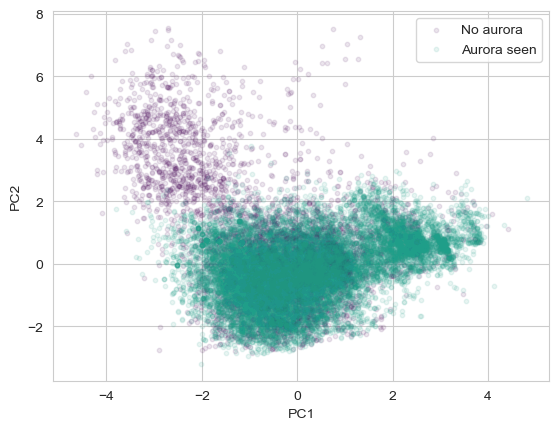

In [156]:
colors = {True: "#1f9e89", False: "#440154"}
labels = {True: "Aurora seen", False: "No aurora"}

for cls in [False, True]:
    mask = (y == cls)
    plt.scatter(transformed_data[mask, 0], transformed_data[mask, 1],
                c=colors[cls], label=labels[cls], alpha=0.1, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

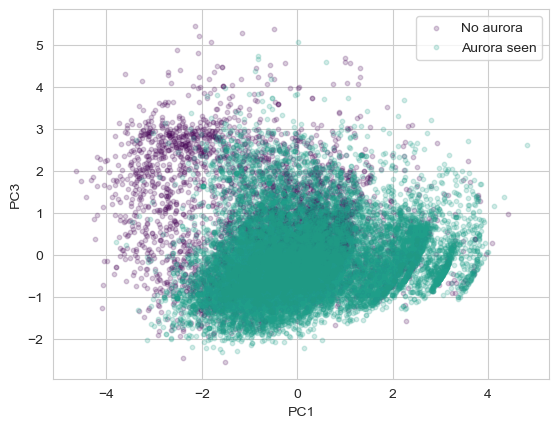

In [157]:
colors = {True: "#1f9e89", False: "#440154"}
labels = {True: "Aurora seen", False: "No aurora"}

for cls in [False, True]:
    mask = (y == cls)
    plt.scatter(transformed_data[mask, 0], transformed_data[mask, 2],
                c=colors[cls], label=labels[cls], alpha=0.2, s=10)

plt.xlabel("PC1")
plt.ylabel("PC3")
plt.legend()
plt.show()

In [158]:
pca = pipe.named_steps["pca"]         

pca.explained_variance_ratio_



array([0.24825224, 0.22060503, 0.12908968, 0.11884696, 0.11597606,
       0.09853903, 0.04112779, 0.02756322])

In [173]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Scale and run PCA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=5)
scores = pca.fit_transform(X_scaled)

print("Explained variance ratios:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.3f} ({ev*100:.1f} %)")
print(f"  Cumulative (PC1-5): {pca.explained_variance_ratio_.sum()*100:.1f} %")

# Loadings
loadings = pca.components_.T  # shape: (n_features, n_components)
feature_names = [f'Metabolite_{i+1}' for i in range(len(features))]

Explained variance ratios:
  PC1: 0.248 (24.8 %)
  PC2: 0.221 (22.1 %)
  PC3: 0.129 (12.9 %)
  PC4: 0.119 (11.9 %)
  PC5: 0.116 (11.6 %)
  Cumulative (PC1-5): 83.3 %


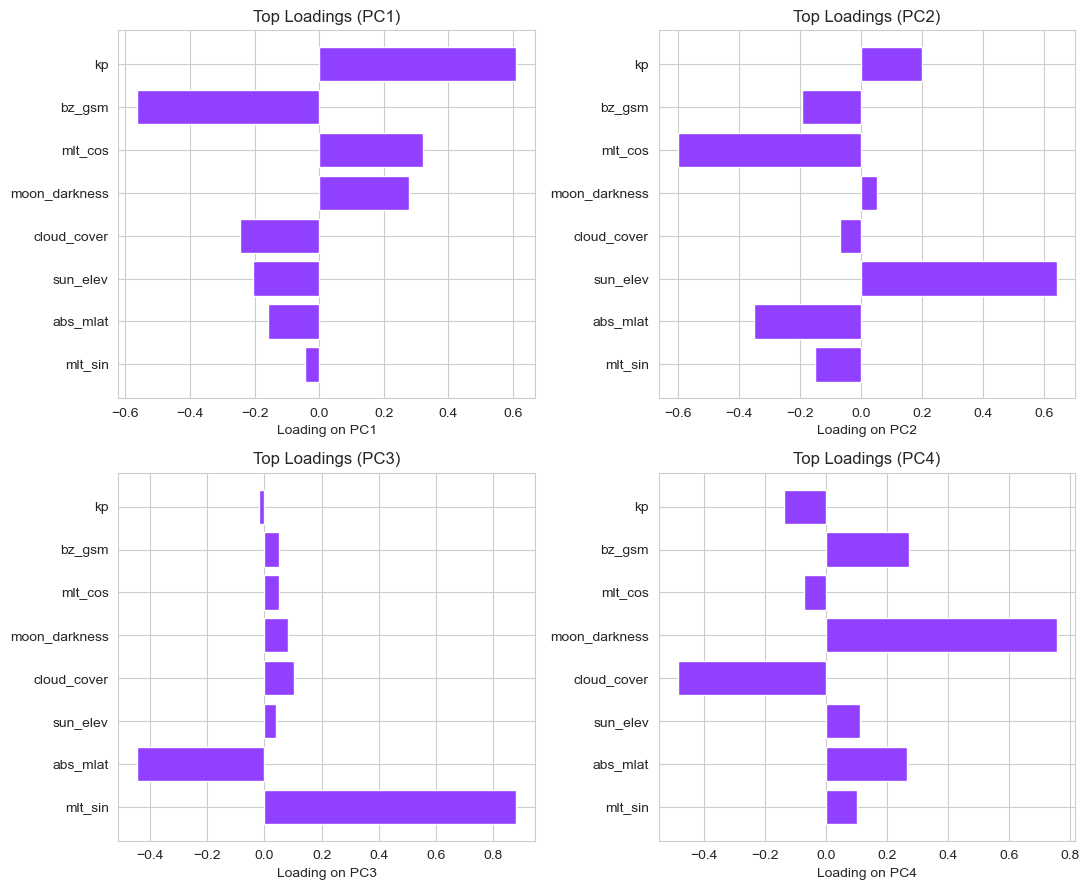

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#code adapted from https://plotivy.app/techniques/pca-visualization


X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=5)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T
feat_names = features
ev = pca.explained_variance_ratio_


fig, axes = plt.subplots(2, 2, figsize=(11, 9))

order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 0].barh(range(len(order)), loadings[order, 0], color='#9240ff')
axes[0, 0].set_yticks(range(len(order)))
axes[0, 0].set_yticklabels([feat_names[i] for i in order])
axes[0, 0].set_xlabel('Loading on PC1')
axes[0, 0].set_title('Top Loadings (PC1)')
axes[0, 0].invert_yaxis()


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 1].barh(range(len(order)), loadings[order, 1], color='#9240ff')
axes[0, 1].set_yticks(range(len(order)))
axes[0, 1].set_yticklabels([feat_names[i] for i in order])
axes[0, 1].set_xlabel('Loading on PC2')
axes[0, 1].set_title('Top Loadings (PC2)')
axes[0, 1].invert_yaxis()

# 3. Loadings bar chart (PC3)
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 0].barh(range(len(order)), loadings[order, 2], color='#9240ff')
axes[1, 0].set_yticks(range(len(order)))
axes[1, 0].set_yticklabels([feat_names[i] for i in order])
axes[1, 0].set_xlabel('Loading on PC3')
axes[1, 0].set_title('Top Loadings (PC3)')
axes[1, 0].invert_yaxis()

# 4. Loadings bar chart (PC4)
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 1].barh(range(len(order)), loadings[order, 3], color='#9240ff')
axes[1, 1].set_yticks(range(len(order)))
axes[1, 1].set_yticklabels([feat_names[i] for i in order])
axes[1, 1].set_xlabel('Loading on PC4')
axes[1, 1].set_title('Top Loadings (PC4)')
axes[1, 1].invert_yaxis()


plt.tight_layout()
plt.savefig('pca_4panel.png', dpi=300, bbox_inches='tight')
plt.show()

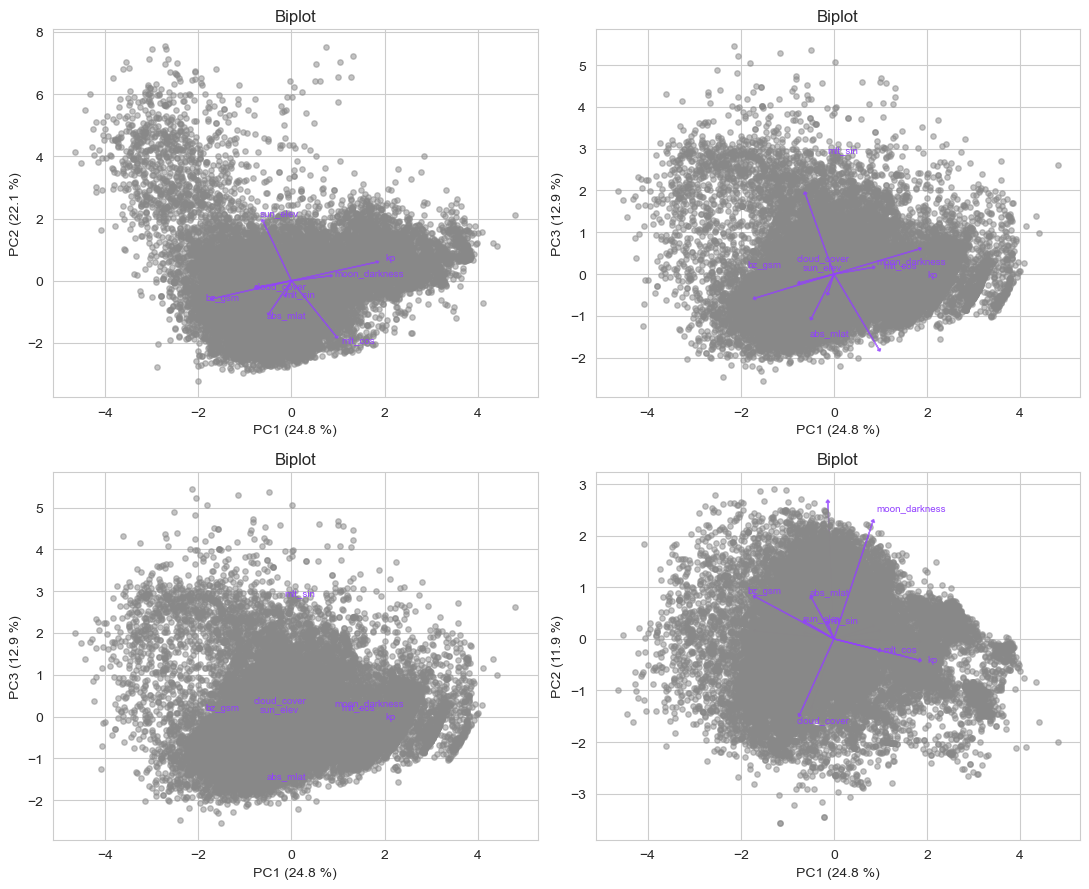

In [ ]:
#code adapted from https://plotivy.app/techniques/pca-visualization


fig, axes = plt.subplots(2, 2, figsize=(11, 9))

order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 0].scatter(scores[:, 0], scores[:, 1], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[0, 0].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[0, 0].text(loadings[i, 0]*scale*1.1, loadings[i, 1]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[0, 0].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[0, 0].set_ylabel(f'PC2 ({ev[1]*100:.1f} %)')
axes[0, 0].set_title('Biplot')


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 1].scatter(scores[:, 0], scores[:, 2], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[0, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[0, 1].text(loadings[i, 0]*scale*1.1, loadings[i, 2]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[0, 1].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[0, 1].set_ylabel(f'PC3 ({ev[2]*100:.1f} %)')
axes[0, 1].set_title('Biplot')

#
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 0].scatter(scores[:, 0], scores[:, 2], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[1, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 2]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[1, 0].text(loadings[i, 0]*scale*1.1, loadings[i, 2]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[1, 0].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[1, 0].set_ylabel(f'PC3 ({ev[2]*100:.1f} %)')
axes[1, 0].set_title('Biplot')


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 1].scatter(scores[:, 0], scores[:, 3], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[1, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 3]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[1, 1].text(loadings[i, 0]*scale*1.1, loadings[i, 3]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[1, 1].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[1, 1].set_ylabel(f'PC2 ({ev[3]*100:.1f} %)')
axes[1, 1].set_title('Biplot')


plt.tight_layout()
plt.savefig('pca_4panel.png', dpi=300, bbox_inches='tight')
plt.show()








Gives the breakdown of what goes into each of the components of the first three compoenents.  

Baseline accuracy : 0.712
Physics-rule accuracy  : 0.353

--- Logistic Regression ---  ROC-AUC: 0.608
              precision    recall  f1-score   support

  didn't see       0.34      0.62      0.44      1254
         saw       0.77      0.51      0.62      3103

    accuracy                           0.54      4357
   macro avg       0.55      0.57      0.53      4357
weighted avg       0.65      0.54      0.56      4357


--- Random Forest ---  ROC-AUC: 0.689
              precision    recall  f1-score   support

  didn't see       0.52      0.36      0.42      1254
         saw       0.77      0.86      0.81      3103

    accuracy                           0.72      4357
   macro avg       0.64      0.61      0.62      4357
weighted avg       0.70      0.72      0.70      4357


--- Gradient Boosting ---  ROC-AUC: 0.694
              precision    recall  f1-score   support

  didn't see       0.47      0.43      0.45      1254
         saw       0.78      0.80      0.79      3103

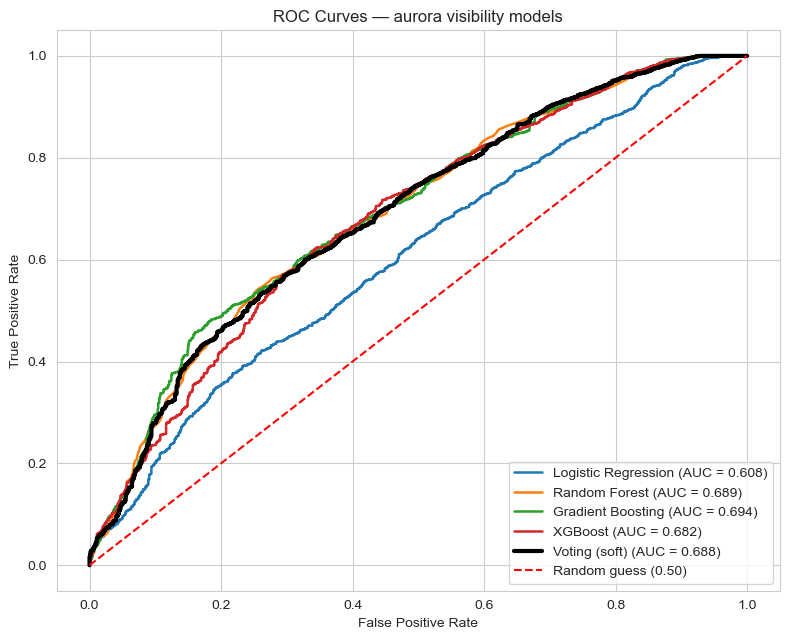

In [161]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier, VotingClassifier)
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                             classification_report, accuracy_score)

from xgboost import XGBClassifier
    


df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", utc=True)

impossible = (df["see_aurora"] == True) & (df["sun_elev"] > 0) #remove the sightings during the day
df = df[~impossible].sort_values("timestamp").reset_index(drop=True)

features = ["abs_mlat", "kp", "bz_gsm", "cloud_cover",
            "moon_darkness", "mlt_sin", "mlt_cos", "sun_elev"]
target = "see_aurora"
df = df.dropna(subset=features + [target]).reset_index(drop=True)

X = df[features]
y = df[target].astype(int)

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

baseline = max(y_test.mean(), 1 - y_test.mean())
physics = (X_test["abs_mlat"] >= 66 - 2*X_test["kp"]).astype(int)
print(f"Baseline accuracy : {baseline:.3f}")
print(f"Physics-rule accuracy  : {accuracy_score(y_test, physics):.3f}")

spw = (y_train == 0).sum() / (y_train == 1).sum()   # XGBoost imbalance weight

lr = LogisticRegression(max_iter=2000, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0, n_jobs=-1)
gb = HistGradientBoostingClassifier(random_state=0)

models = {"Logistic Regression": lr, "Random Forest": rf, "Gradient Boosting": gb}
vote_estimators = [("lr", lr), ("rf", rf), ("gb", gb)]


xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        scale_pos_weight=spw, eval_metric="logloss",
                        random_state=0, n_jobs=-1)
models["XGBoost"] = xgb
vote_estimators.append(("xgb", xgb))

models["Voting (soft)"] = VotingClassifier(estimators=vote_estimators, voting="soft")

for name, model in models.items():
    model.fit(X_train, y_train)
    auc_v = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\n--- {name} ---  ROC-AUC: {auc_v:.3f}")
    print(classification_report(y_test, model.predict(X_test), target_names=["didn't see", "saw"]))

start = pd.Timestamp("2021-01-01", tz="utc")
dfw = df[df["timestamp"] >= start].reset_index(drop=True)
n_windows = 6
edges = pd.date_range(start, dfw["timestamp"].max(), periods=n_windows + 1)
print("\nWalk-forward validation:")
for name, model in models.items():
    scores = []
    for i in range(1, n_windows + 1):
        te = (dfw["timestamp"] >= edges[i-1]) & (dfw["timestamp"] < edges[i])
        tr = dfw["timestamp"] < edges[i-1]
        if tr.sum() < 500 or te.sum() < 50: continue
        yte = dfw.loc[te, target].astype(int)
        if yte.nunique() < 2: continue
        model.fit(dfw.loc[tr, features], dfw.loc[tr, target].astype(int))
        scores.append(roc_auc_score(yte, model.predict_proba(dfw.loc[te, features])[:, 1]))
    print(f"  {name:22s}: AUC {np.mean(scores):.3f} ± {np.std(scores):.3f}  ({len(scores)} windows)")

for model in models.values(): model.fit(X_train, y_train)
plt.figure(figsize=(8, 6.5))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    style = dict(lw=3, color="black") if name == "Voting (soft)" else dict(lw=1.8)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})", **style)
plt.plot([0, 1], [0, 1], "r--", label="Random guess (0.50)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — aurora visibility models")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

Below separates the models used into four graphs.

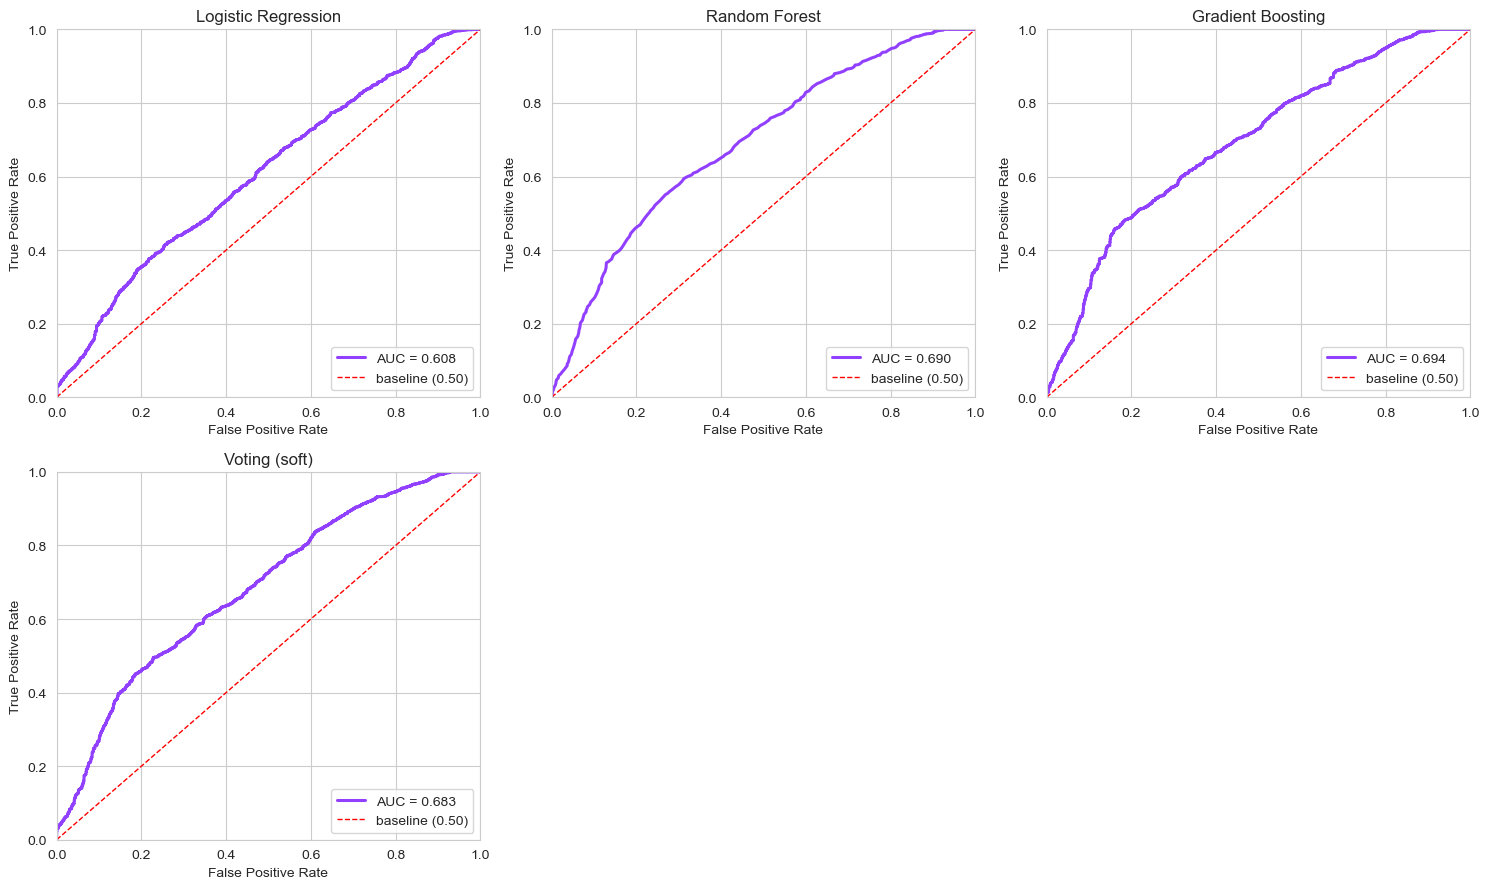

In [172]:

X = df[features]; y = df["see_aurora"].astype(int)
s = int(len(df)*0.8); X_train, X_test = X.iloc[:s], X.iloc[s:]; y_train, y_test = y.iloc[:s], y.iloc[s:]

# ---- models ----
lr = LogisticRegression(max_iter=2000, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0, n_jobs=-1)
gb = HistGradientBoostingClassifier(random_state=0)
vote = VotingClassifier(estimators=[("lr",lr),("rf",rf),("gb",gb)], voting="soft")
models = {"Logistic Regression": lr, "Random Forest": rf,
          "Gradient Boosting": gb, "Voting (soft)": vote}
for m in models.values(): m.fit(X_train, y_train)

n = len(models); cols = 3; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.5*rows))
axes = np.array(axes).reshape(-1)

for ax, (name, model) in zip(axes, models.items()):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.2, color="#9240ff", label=f"AUC = {a:.3f}")
    ax.plot([0, 1], [0, 1], "r--", lw=1, label="baseline (0.50)")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(name); ax.legend(loc="lower right")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\anaco\AppData\Local\Temp\ipykernel_61012\609789421.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", max_display=8, show=False)


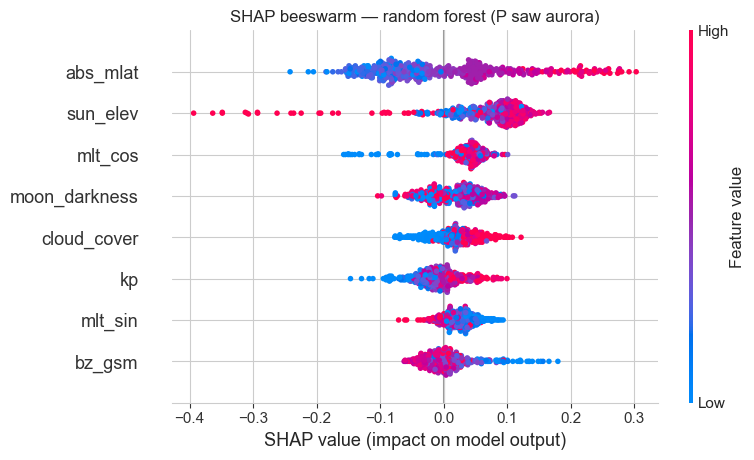

In [ ]:
import shap                       # pip install shap

df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", utc=True)
df = df[~((df["see_aurora"] == True) & (df["sun_elev"] > 0))]
df = df.sort_values("timestamp").reset_index(drop=True)

features = ["abs_mlat", "kp", "bz_gsm", "cloud_cover",
            "moon_darkness", "mlt_sin", "mlt_cos", "sun_elev"]
df = df.dropna(subset=features + ["see_aurora"]).reset_index(drop=True)

X = df[features]
y = df["see_aurora"].astype(int)

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train = y.iloc[:split]


rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                            random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)


X_sample = X_test.sample(min(500, len(X_test)), random_state=0)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)


sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 1]


shap.summary_plot(sv, X_sample, plot_type="dot", max_display=8, show=False)
plt.title("SHAP beeswarm — random forest (P saw aurora)")
plt.tight_layout()
plt.show()

In [164]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

df = df[~((df["see_aurora"] == True) & (df["sun_elev"] > 0))]
df = df.sort_values("timestamp").reset_index(drop=True)        # MUST be time-ordered

features = ["abs_mlat","kp","bz_gsm","cloud_cover","moon_darkness","mlt_sin","mlt_cos","sun_elev"]
X = df[features]
y = df["see_aurora"].astype(int)

# ---- the grid: parameters to try ----
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
}

# ---- TIME-AWARE cross-validation (the critical part) ----
tscv = TimeSeriesSplit(n_splits=4)

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1),
    param_grid,
    cv=tscv,                 # <-- time-ordered folds, NOT random
    scoring="roc_auc",       # tune for AUC, not accuracy
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y)

print("best params:", grid.best_params_)
print("best CV AUC:", round(grid.best_score_, 3))

Fitting 4 folds for each of 54 candidates, totalling 216 fits
best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
best CV AUC: 0.758


In [165]:


features = ["abs_mlat","kp","bz_gsm","cloud_cover","moon_darkness","mlt_sin","mlt_cos","sun_elev"]
df = df.dropna(subset=features + ["see_aurora"]).reset_index(drop=True)

start = pd.Timestamp("2021-01-01", tz="utc")
dfw = df[df["timestamp"] >= start].reset_index(drop=True)
n_windows = 6
edges = pd.date_range(start, dfw["timestamp"].max(), periods=n_windows + 1)

untuned = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 random_state=0, n_jobs=-1)
tuned   = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=20,
                                 max_features="sqrt", class_weight="balanced",
                                 random_state=0, n_jobs=-1)

for name, model in [("UNTUNED", untuned), ("TUNED", tuned)]:
    scores = []
    for i in range(1, n_windows + 1):
        te = (dfw["timestamp"] >= edges[i-1]) & (dfw["timestamp"] < edges[i])
        tr = dfw["timestamp"] < edges[i-1]
        if tr.sum() < 500 or te.sum() < 50:
            continue
        yte = dfw.loc[te, "see_aurora"].astype(int)
        if yte.nunique() < 2:
            continue
        model.fit(dfw.loc[tr, features], dfw.loc[tr, "see_aurora"].astype(int))
        scores.append(roc_auc_score(yte, model.predict_proba(dfw.loc[te, features])[:, 1]))
    print(f"{name}: AUC {np.mean(scores):.3f} ± {np.std(scores):.3f}")

UNTUNED: AUC 0.723 ± 0.025
TUNED: AUC 0.729 ± 0.022


In [166]:

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

df = df[~((df["see_aurora"] == True) & (df["sun_elev"] > 0))]
df = df.sort_values("timestamp").reset_index(drop=True)

features = ["abs_mlat","kp","bz_gsm","cloud_cover","moon_darkness","mlt_sin","mlt_cos","sun_elev"]
X = df[features]
y = df["see_aurora"].astype(int)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
}


tscv = TimeSeriesSplit(n_splits=4)

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y)

print("best params:", grid.best_params_)
print("best CV AUC:", round(grid.best_score_, 3))

Fitting 4 folds for each of 54 candidates, totalling 216 fits
best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 200}
best CV AUC: 0.759


In [167]:



df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", utc=True)
df = df[~((df["see_aurora"] == True) & (df["sun_elev"] > 0))].sort_values("timestamp").reset_index(drop=True)

features = ["abs_mlat","kp","bz_gsm","cloud_cover","moon_darkness","mlt_sin","mlt_cos","sun_elev"]
df = df.dropna(subset=features + ["see_aurora"]).reset_index(drop=True)

X = df[features]
y = df["see_aurora"].astype(int)
tscv = TimeSeriesSplit(n_splits=4)

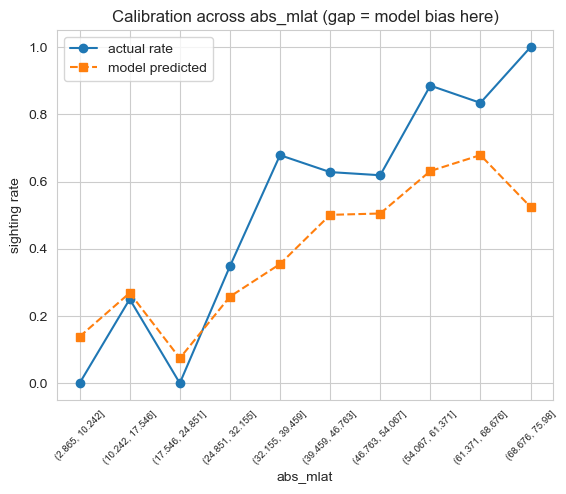

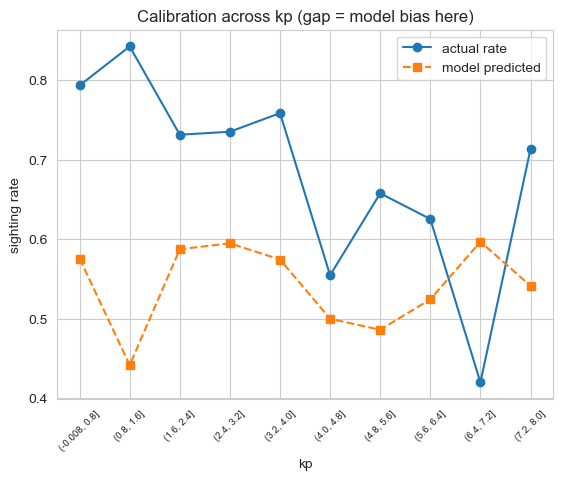

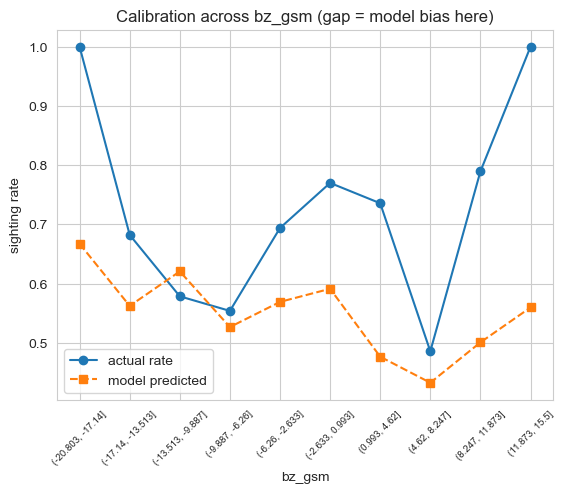

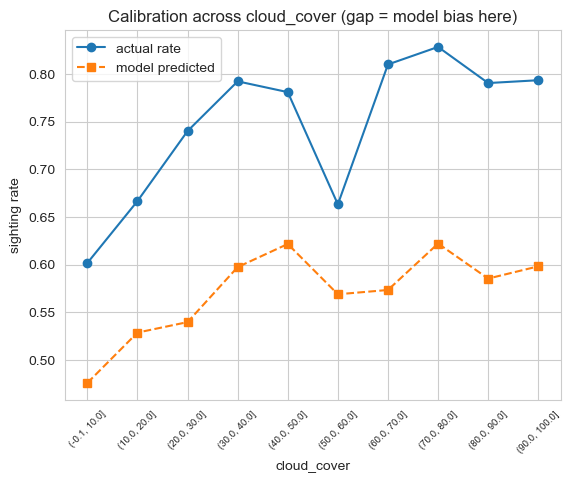

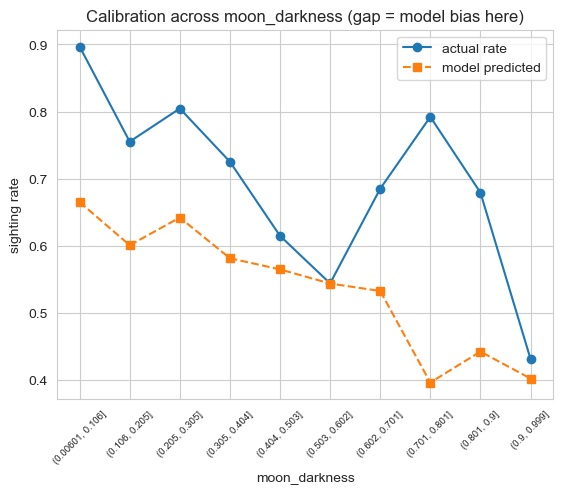

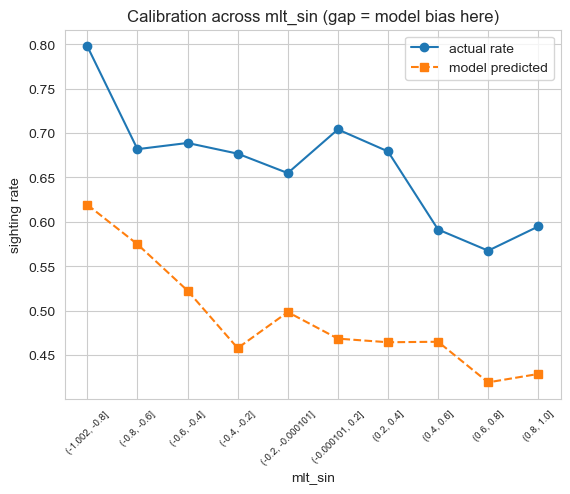

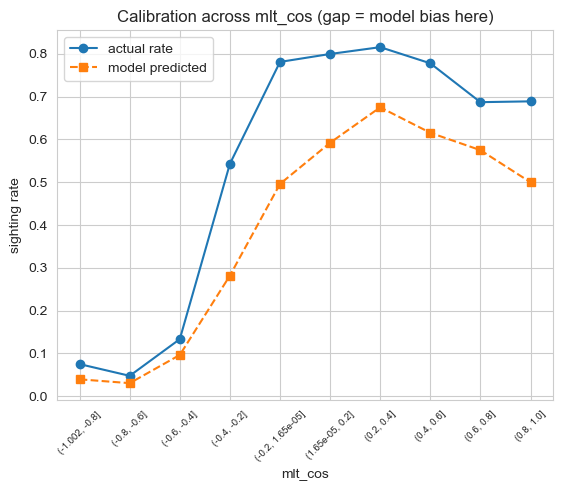

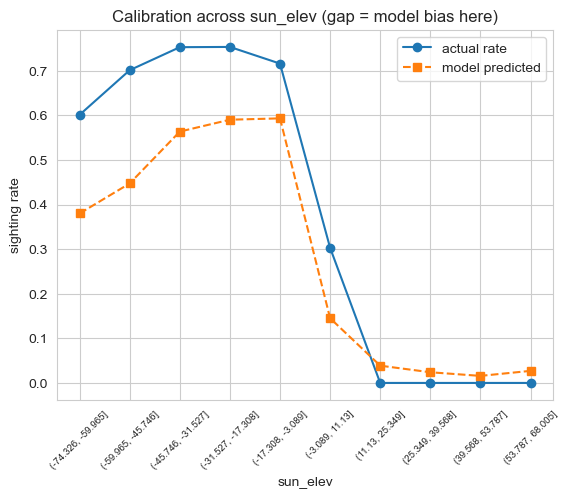

In [171]:
test = X_test.copy()
test["actual"] = y_test.values
test["pred"]   = model.predict_proba(X_test)[:, 1]

features= ['abs_mlat', 'kp', 'bz_gsm', 'cloud_cover', 'moon_darkness', 'mlt_sin', 'mlt_cos', 'sun_elev']

for feature in features:
    test["bin"] = pd.cut(test[feature], bins=10)
    g = test.groupby("bin", observed=True).agg(actual_rate=("actual","mean"),
                                            pred_rate=("pred","mean"),
                                            n=("actual","size"))

    plt.plot(range(len(g)), g["actual_rate"], "o-", label="actual rate")
    plt.plot(range(len(g)), g["pred_rate"],   "s--", label="model predicted")
    plt.xticks(range(len(g)), [str(b) for b in g.index], rotation=45, fontsize=7)
    plt.xlabel(feature); plt.ylabel("sighting rate"); plt.legend()
    plt.title(f"Calibration across {feature} (gap = model bias here)")
    plt.show()